# Notebook for practical exercises | Week #6 Lesson #2

### Foundation Model Adaptation for Medical Imaging

In this notebook, we shift our focus from training models from scratch to adapting large, pre-trained *Foundation Models*. Our goal remains to improve diagnostic accuracy on the [NIH ChestX-ray-14](https://nihcc.app.box.com/v/ChestXray-NIHCC) dataset by combining image and tabular data. However, this time we will leverage the powerful visual features learned by *MedCLIP*, a Vision-Language Model pre-trained on a massive corpus of medical images and text.

Instead of full fine-tuning, which can be computationally expensive and prone to overfitting on smaller datasets, we will explore and compare three popular and parameter-efficient adaptation strategies:

1.  Linear Probing: The quickest adaptation method. We freeze the entire foundation model and only train a single new linear layer (a classifier) on top of the extracted features.
2.  Partial Fine-Tuning: A step up from linear probing. We add a small Multi-Layer Perceptron (MLP) as a new classification head and only train its parameters, keeping the backbone frozen.
3.  LoRA (Low-Rank Adaptation): A sophisticated and efficient fine-tuning technique. We freeze the backbone but inject small, trainable "adapter" layers into the model's architecture. This allows us to update the model's behavior without altering the original weights.

Finally, we will compare the performance (AUC, Accuracy, F1) and training cost (number of trainable parameters) of these methods against a **DenseNet-121 baseline** trained from scratch to highlight the effectiveness and efficiency of foundation model adaptation.


## Dataset

[NIH ChestX-ray-14](https://nihcc.app.box.com/v/ChestXray-NIHCC) dataset comprises 112,120 frontal-view X-ray images of 30,805 unique patients with the text-mined fourteen disease image labels (where each image can have multi-labels), mined from the associated radiological reports using natural language processing.
Fourteen common thoracic pathologies include Atelectasis, Consolidation, Infiltration, Pneumothorax, Edema, Emphysema, Fibrosis, Effusion, Pneumonia, Pleural_thickening, Cardiomegaly, Nodule, Mass and Hernia.

It contains:
1. 112,120 frontal-view chest X-ray PNG images in 1024*1024 resolution (under images folder)
2. Meta data for all images (Data_Entry_2017.csv): Image Index, Finding Labels, Follow-up #, Patient ID, Patient Age, Patient Gender, View Position, Original Image Size and Original Image Pixel Spacing.
3. Bounding boxes for ~1000 images (BBox_List_2017.csv): Image Index, Finding Label, Bbox[x, y, w, h]. [x y] are coordinates of each box's topleft corner. [w h] represent the width and height of each box.
4. The data split from previous week
Here, we will use a subsample of this dataset along with pretrained models from the last week.

## Download

In [ ]:
# !curl https://uni-bonn.sciebo.de/s/SmXWRLyRBYR6SZ3/download/test_df.csv --output {DATA_PATH}/test_df.csv
# !curl https://uni-bonn.sciebo.de/s/KN4JYbasBYwy4AG/download/train_df.csv --output {DATA_PATH}/train_df.csv
# !curl https://uni-bonn.sciebo.de/s/CZL5WBaDYEDgmJq/download/val_df.csv --output {DATA_PATH}/val_df.csv

# !curl https://uni-bonn.sciebo.de/s/J3GFK3bsHGDfwAC/download/data_cxr8.zip --output {DATA_PATH}/data.zip
# !unzip {DATA_PATH}/data.zip -d {DATA_PATH}

In [ ]:
#@title import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings(action="ignore")

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from PIL import Image
from tqdm.notebook import tqdm

from transformers import AutoProcessor, AutoModel
from peft import get_peft_model, LoraConfig, TaskType

import random
def set_seed(seed):
    """Set seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Seed set to {seed}")

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Seed set to 42
Using device: cuda


## Load data

In [ ]:
# Load the data splits
DATA_PATH = './' # Ensure this path is correct
train_df = pd.read_csv(f'{DATA_PATH}/train_df.csv')
val_df = pd.read_csv(f'{DATA_PATH}/val_df.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test_df.csv') # Renaming to test_df for clarity

IMG_DIR = f'{DATA_PATH}/data/CXR8/images'
train_df['ImagePath'] = train_df['Image Index'].apply(lambda x: os.path.join(IMG_DIR, x))
val_df['ImagePath'] = val_df['Image Index'].apply(lambda x: os.path.join(IMG_DIR, x))
test_df['ImagePath'] = test_df['Image Index'].apply(lambda x: os.path.join(IMG_DIR, x))

print("Data loaded successfully.")
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Data loaded successfully.
Training samples: 2817
Validation samples: 313
Test samples: 783


## Preprocessing and data creation


We'll use the same tabular preprocessing functions as in previous exercise. The main change is in the `Dataset` class, where we will now use the specific processor from the MedCLIP model to prepare the images.

Next, we'll create a custom PyTorch `Dataset`. This class needs to handle both images and tabular data. For each sample, it will use the MedCLIP `processor` for the image and our `preprocess_tabular` function for the metadata.

Complete the `__getitem__` method in the `MultiModalFMDataset` class.

In [ ]:
min_age = train_df['Patient Age'].min()
max_age = train_df['Patient Age'].max()

def normalize_age(age):
    return (age - min_age) / (max_age - min_age)

def one_hot_sex(sex):
    return [1, 0] if sex == 'F' else [0, 1]

sample_row = train_df.iloc[0]
age_norm = normalize_age(sample_row['Patient Age'])
sex_onehot = one_hot_sex(sample_row['Patient Sex'])
tabular_vector = np.array([age_norm] + sex_onehot, dtype=np.float32)

print(f"Sample Patient Age: {sample_row['Patient Age']}, Sex: {sample_row['Patient Sex']}")
print(f"Processed Tabular Vector: {tabular_vector}")
print(f"Size of our tabular feature vector: {len(tabular_vector)}")

class MultiModalFMDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.image_paths = df['ImagePath'].tolist()
        self.ages = df['Patient Age'].tolist()
        self.sexes = df['Patient Sex'].tolist()
        self.labels = df['Binary Label'].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Image Data
        # Open the image file
        image = Image.open(self.image_paths[idx]).convert('RGB')
        # Use the MedCLIP processor to prepare the image
        image_inputs = processor(...#COMPLETE)
        # Extract the processed tensor and remove the batch dimension
        image_tensor = image_inputs['pixel_values'].squeeze(0)

        # Tabular Data
        # Use the same function as before to process metadata
        tabular_tensor = preprocess_tabular(...#COMPLETE)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return image_tensor, tabular_tensor, label


# Create datasets
train_dataset = MultiModalFMDataset(train_df)
val_dataset = MultiModalFMDataset(val_df)
test_dataset = MultiModalFMDataset(test_df)

# Create dataloaders with drop_last=True to avoid the shape mismatch error
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    drop_last=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    drop_last=False
)
test_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    drop_last=False
)

print("\n MedCLIP processor and DataLoaders are ready.")

Sample Patient Age: 68, Sex: F
Processed Tabular Vector: [0.72043014 1.         0.        ]
Size of our tabular feature vector: 3

 MedCLIP processor and DataLoaders are ready.


### Defining Adaptation Models

Here we define the three adaptation strategies. All models will use the same pre-trained MedCLIP vision backbone, but differ in which parameters are made trainable.

1.  Linear Probing: Freeze the backbone and train a single linear layer.
2.  Partial Fine-Tuning: Freeze the backbone and train a new, small MLP head.
3.  LoRA Adaptation: Freeze the backbone, inject trainable LoRA adapters, and train a new MLP head.

Task: The core structure is provided. Your task is to complete the forward pass for each.

In [ ]:
# Load MedCLIP Model and Processor
processor = AutoProcessor.from_pretrained("flaviagiammarino/pubmed-clip-vit-base-patch32")
medclip_model   = AutoModel.from_pretrained("flaviagiammarino/pubmed-clip-vit-base-patch32")

# freeze every parameter in the vision backbone + its projection head
for param in medclip_model.vision_model.parameters():
    param.requires_grad = False
# for param in medclip_model.visual_projection.parameters():
#     param.requires_grad = False

IMAGE_EMBED_DIM = medclip_model.visual_projection.out_features

# Preprocessing Proxy Attributes
PROJECTION_MAP = {'AP': [1.0, 0.0, 0.0], 'PA': [0.0, 1.0, 0.0]}
# Calculate the size of the tabular feature vector
TABULAR_FEATURE_SIZE = len(PROJECTION_MAP['AP']) + 1  # One-hot for projection + 1 for portable

def preprocess_tabular(projection, is_portable):
    proj_onehot = PROJECTION_MAP.get(projection, [0.0, 0.0, 0.0]) # Default for safety
    port_float = [1.0] if is_portable else [0.0]
    return torch.tensor(proj_onehot + port_float, dtype=torch.float32)


# Linear Probing Model
class LinearProbeModel(nn.Module):
    def __init__(self, vision_model, num_img_features, num_tabular_features):
        super().__init__()
        self.vision_model = vision_model
        # The only trainable part is this single linear layer
        self.classifier = nn.Linear(num_img_features + num_tabular_features, 1)

    def forward(self, image, tabular):
        # COMPLETE: Get image features, combine with tabular, and classify
        img_features = self.vision_model.get_image_ ... #COMPLETE
        combined_features = torch.cat([...#COMPLETE], dim=1)
        return self.classifier(combined_features)

# Partial Fine-Tuning Model
class PartialFTModel(nn.Module):
    def __init__(self, vision_model, num_img_features, num_tabular_features):
        super().__init__()
        self.vision_model = vision_model
        # The only trainable part is this new MLP head
        self.classifier = nn.Sequential(
            nn.Linear(num_img_features + num_tabular_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_features = ...#COMPLETE
        combined_features = ...#COMPLETE
        return self.classifier(combined_features)

# LoRA Adaptation Model
class LoRAModel(nn.Module):
    def __init__(self, vision_model, num_img_features, num_tabular_features):
        super().__init__()
        lora_config = LoraConfig(
            r=16, # Rank of the low-rank matrices
            lora_alpha=16, # Scaling factor
            lora_dropout=0.1,
            bias="none",
            target_modules=["q_proj", "v_proj"] # Apply LoRA to query and value projections in attention
        )
        # This injects the trainable LoRA adapters into the vision model
        self.vision_model = get_peft_model(vision_model, lora_config)

        # We also train this new MLP head
        self.classifier = nn.Sequential(
            nn.Linear(...#COMPLETE),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_features = ...#COMPLETE
        combined_features = ...#COMPLETE
        return self.classifier(combined_features)

### Training and Evaluating Adapted Models

Complete the missing parts of the training loop: the loss calculation, backpropagation, and optimizer step.

In [ ]:
def train_and_evaluate_fm(model, model_name, train_loader, val_loader, epochs=7):
    # Load MedCLIP Model and Processor
    processor = AutoProcessor.from_pretrained("flaviagiammarino/pubmed-clip-vit-base-patch32")
    medclip_model   = AutoModel.from_pretrained("flaviagiammarino/pubmed-clip-vit-base-patch32")

    # freeze every parameter in the vision backbone + its projection head
    for param in medclip_model.vision_model.parameters():
        param.requires_grad = False
    print(f"--- Training {model_name} ---")
    model.to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    best_val_auc = 0
    best_val_acc = 0
    best_val_f1 = 0
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, tabular, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
            optimizer....#COMPLETE
            outputs = ...#COMPLETE
            loss = ...#COMPLETE
            loss backward ...#COMPLETE
            optimizer step ...#COMPLETE
            total_loss += loss.item()

        # Validation
        model.eval()
        all_labels, all_probs = [], []
        with torch.no_grad():
            for images, tabular, labels in val_loader:
                images, tabular = images.to(device), tabular.to(device)
                outputs = model(images, tabular)
                probs = torch.sigmoid(outputs.squeeze())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_auc = roc_auc_score(...#COMPLETE)
        val_acc = accuracy_score(...#COMPLETE)
        val_f1 = f1_score(...#COMPLETE)
        print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f} | Val Acc: {val_acc:.4f}")
        if val_auc > best_val_auc:
            best_val_auc = val_auc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1

    return {'name': model_name, 'auc': best_val_auc, 'acc': best_val_acc, 'f1': best_val_f1, 'params': sum(p.numel() for p in model.parameters() if p.requires_grad)}


# Instantiate and run evaluations
results = []

linear_probe_model = LinearProbeModel(medclip_model, IMAGE_EMBED_DIM, TABULAR_FEATURE_SIZE)
results.append(train_and_evaluate_fm(linear_probe_model, "Linear Probing (MedCLIP)", train_loader, val_loader))

partial_ft_model = PartialFTModel(medclip_model, IMAGE_EMBED_DIM, TABULAR_FEATURE_SIZE)
results.append(train_and_evaluate_fm(partial_ft_model, "Partial FT (MedCLIP)", train_loader, val_loader))

lora_model = LoRAModel(medclip_model, IMAGE_EMBED_DIM, TABULAR_FEATURE_SIZE)
results.append(train_and_evaluate_fm(lora_model, "LoRA (MedCLIP)", train_loader, val_loader))

--- Training Linear Probing (MedCLIP) ---


Epoch 1:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.3010 | Val AUC: 0.8769 | Val Acc: 0.8275


Epoch 2:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.0714 | Val AUC: 0.8771 | Val Acc: 0.8403


...

Epoch 5 | Train Loss: 0.2903 | Val AUC: 0.8859 | Val Acc: 0.8243


Epoch 6:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 6 | Train Loss: 0.2468 | Val AUC: 0.8812 | Val Acc: 0.8275


Epoch 7:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 7 | Train Loss: 0.2149 | Val AUC: 0.8795 | Val Acc: 0.8211


### Baseline Model (Unimodel)

To properly evaluate our foundation model adaptation, we will bring our unimodel baseline. We'll use the DenseNet-121 model from previous lessons. This will show us the performance gain from both the foundation model's pre-trained features and the fusion of tabular data.

In [ ]:
# !curl https://uni-bonn.sciebo.de/s/KmZ98EP7zBLLBmE/download/densenet121-classification_.pth --output ./densenet121-classification.pth


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 27.1M  100 27.1M    0     0  44.1M      0 --:--:-- --:--:-- --:--:-- 44.1M


In [ ]:
#@title helper
from torchvision import transforms, models

baseline_model = models.densenet121(pretrained=True)
baseline_model.classifier = nn.Linear(baseline_model.classifier.in_features, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model.load_state_dict(torch.load('./densenet121-classification.pth', map_location=device))

class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image Index'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['Binary Label'], dtype=torch.float32)
        return image, label

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

image_size_= 224

train_transforms = transforms.Compose([
    transforms.Resize((image_size_,image_size_)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_transforms   = transforms.Compose([
    transforms.Resize((image_size_,image_size_)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

img_dir  = f'{DATA_PATH}/data/CXR8/images'

test_ds_   = ChestXrayDataset(test_df,   img_dir, transform=val_transforms)
test_loader_baseline   = DataLoader(test_ds_,   batch_size=32, num_workers=32, pin_memory=True)

In [ ]:
# Dataset for baseline image-only model

def evaluate_model(model, loader, model_name, device="cuda"):
    model.eval()
    all_labels = []
    all_probs  = []
    all_preds  = []
    model.to(device) # Move model to the specified device

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs   = torch.sigmoid(outputs.squeeze())
            preds   = (probs > 0.5).long()

            all_labels.extend(labels.cpu().numpy())
            all_probs .extend(probs.cpu().numpy())
            all_preds .extend(preds.cpu().numpy())

    val_auc = roc_auc_score(all_labels, all_probs)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds)

    return {
        'name'  : model_name,
        'auc'   : val_auc,
        'acc'   : val_acc,
        'f1'    : val_f1,
        'params': sum(p.numel() for p in model.parameters() if p.requires_grad)
    }
results.append(evaluate_model(baseline_model, test_loader_baseline, "Baseline (unimodel)"))

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
results

[{'name': 'Linear Probing (MedCLIP)',
  'auc': 0.882154415164124,
  'acc': 0.8434504792332268,
  'f1': 0.751269035532995,
  'params': 983557},
 {'name': 'Partial FT (MedCLIP)',
  'auc': 0.8811835413777163,
  'acc': 0.8434504792332268,
  'f1': 0.7562189054726368,
  'params': 1049345},
 {'name': 'LoRA (MedCLIP)',
  'auc': 0.8859454461396209,
  'acc': 0.8274760383386581,
  'f1': 0.7272727272727273,
  'params': 1049345},
 {'name': 'Baseline (unimodel)',
  'auc': 0.89386900622864,
  'acc': 0.8352490421455939,
  'f1': 0.7615526802218114,
  'params': 6954881}]

### Final Comparison

Run the cell below to generate the comparison table and plot. Then, in a new text cell, answer the following questions:
1.  Which model performed the best in terms of AUC and other metrics? Why do you think that is?
2.  Compare the number of trainable parameters for LoRA vs. the baseline DenseNet. What does this tell you about the efficiency of LoRA?

--- Final Model Comparison ---
                             auc params_formatted
name                                             
Linear Probing (MedCLIP)  0.8822          983,557
Partial FT (MedCLIP)      0.8812        1,049,345
LoRA (MedCLIP)            0.8859        1,049,345
Baseline (unimodel)       0.8939        6,954,881


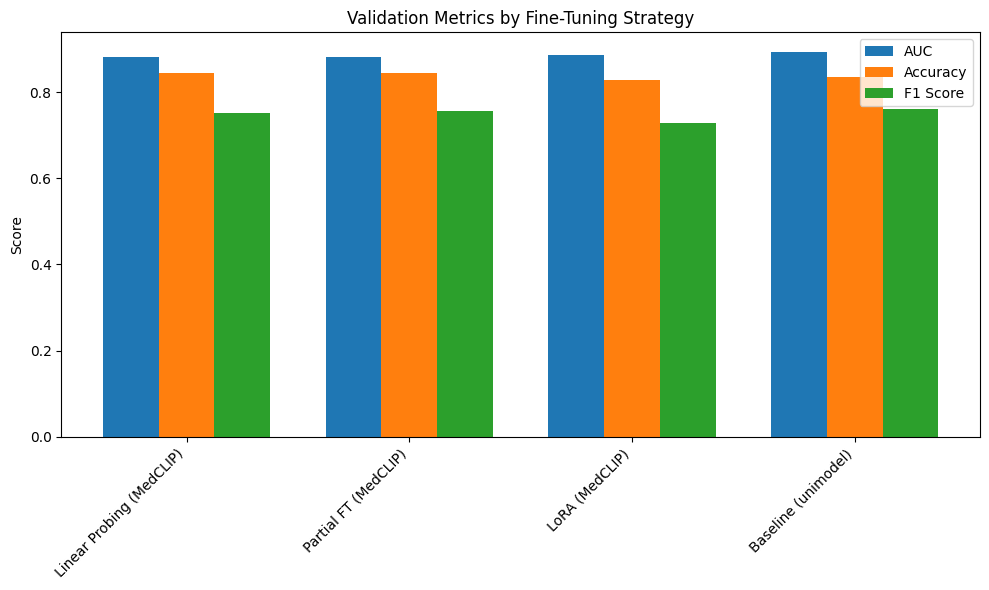

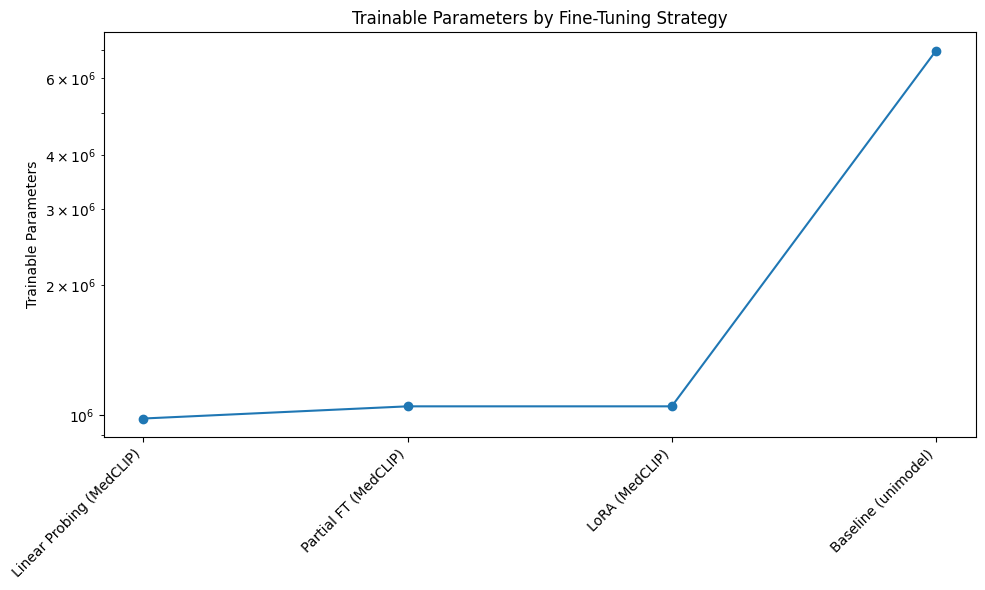

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('name')
results_df['params_formatted'] = results_df['params'].map('{:,}'.format)

print("--- Final Model Comparison ---")
print(results_df[['auc', 'params_formatted']].round(4))

# Grouped bar chart for AUC, Accuracy, F1
metrics = results_df[['auc', 'acc', 'f1']]
x = range(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], metrics['auc'], width, label='AUC')
plt.bar(x,               metrics['acc'], width, label='Accuracy')
plt.bar([i + width for i in x], metrics['f1'], width, label='F1 Score')
plt.xticks(x, metrics.index, rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Validation Metrics by Fine-Tuning Strategy')
plt.legend()
plt.tight_layout()
plt.show()

# Line plot (log scale) for trainable parameters
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['params'], marker='o')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Trainable Parameters')
plt.title('Trainable Parameters by Fine-Tuning Strategy')
plt.tight_layout()
plt.show()


The results clearly demonstrate the power and efficiency of adapting foundation models for specialized medical tasks.

*   Baseline vs. Foundation Models: Which one of the three performed best? why is that?

This exercise illustrates a key paradigm in modern AI development: leveraging large foundation models is often more effective than training specialized models from scratch. Parameter-Efficient Fine-Tuning (PEFT) methods like LoRA offer the best of both worlds—they achieve state-of-the-art performance while being computationally efficient, making them ideal for adapting powerful foundation models to various downstream tasks in medicine and beyond.